In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import files
uploaded=files.upload()

Saving customer_shopping_data.csv to customer_shopping_data.csv


In [7]:
df=pd.read_csv("customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [9]:
df.shape

(99457, 10)

In [10]:
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [11]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [18]:
df['category'].value_counts()

,count
category,
Clothing,34487
Cosmetics,15097
Food & Beverage,14776
Toys,10087
Shoes,10034
Souvenir,4999
Technology,4996
Books,4981


In [20]:
df['gender'].value_counts()

,count
gender,
Female,59482
Male,39975


In [38]:
df['payment_method'].value_counts()

,count
payment_method,
Cash,44447
Credit Card,34931
Debit Card,20079


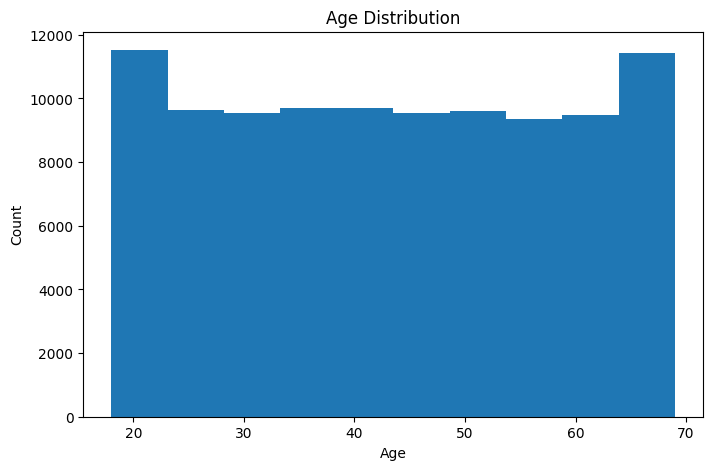

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insight:
The customer ages are evenly distributed between 18 and 70 years,indicating that there is no age limit in shopping activities.

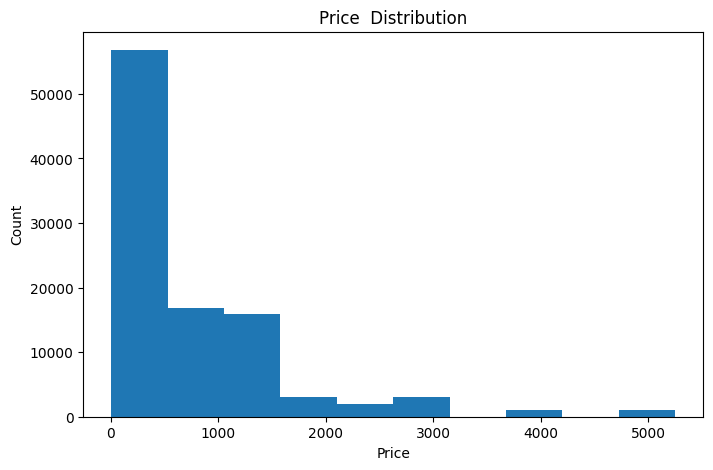

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df['price'])
plt.title("Price  Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Insight:
Most purchases are in  lower prices, only a small number of transaction have very high prices, indicates that customer purchases are generally low to moderate in value.

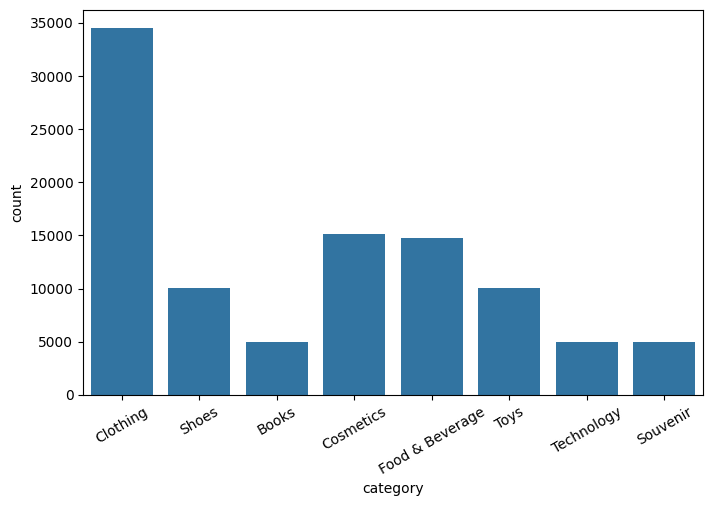

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='category')
plt.xticks(rotation=30)
plt.show()

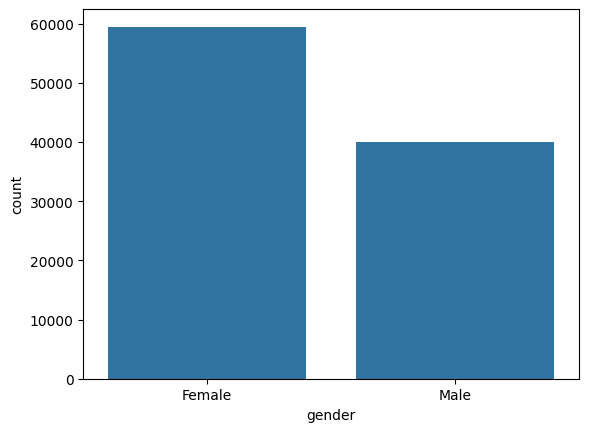

In [30]:
sns.countplot(data=df,x='gender')
plt.show()

Insight:
Females customers account for a higher number of transaction compared to male customers.

In [32]:
mall_sales=df.groupby('shopping_mall')['price'].sum()
mall_sales.sort_values(ascending=False)

,price
shopping_mall,
Mall of Istanbul,13851737.62
Kanyon,13710755.24
Metrocity,10249980.07
Metropol AVM,6937992.99
Istinye Park,6717077.54
Zorlu Center,3509649.02
Cevahir AVM,3433671.84
Viaport Outlet,3414019.46
Emaar Square Mall,3390408.31


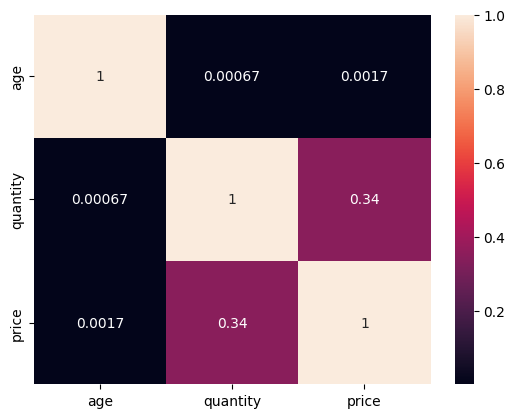

In [37]:
sns.heatmap(df[['age','quantity','price']].corr(),annot=True)
plt.show()

Insight:
There is no meaningful relationship between age and spending. However, quantity and price show a moderate positive relationship, meaning higher quantities generally result in higher purchases amounts.

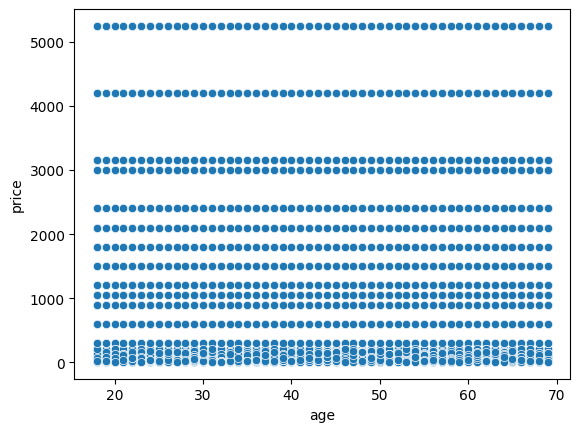

In [39]:
sns.scatterplot(x='age',y='price',data=df)
plt.show()

Insight:
There is no relationship between age and purchase amount. Customers of all ages make both low-value anf high-value purchases.

In [12]:
import sqlite3

In [13]:
conn=sqlite3.connect('shopping.db')
df.to_sql('shopping',conn, if_exists='replace', index=False)
print("Table created successfully!")

Table created successfully!


##Sql business Question 1:
Which product category generates the highest revenue?

In [14]:
query = """
SELECT category, SUM(price) AS total_revenue
FROM shopping
GROUP BY category
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

          category  total_revenue
0         Clothing   3.107568e+07
1            Shoes   1.813534e+07
2       Technology   1.577205e+07
3        Cosmetics   1.848607e+06
4             Toys   1.086705e+06
5  Food & Beverage   2.315687e+05
6            Books   2.269773e+05
7         Souvenir   1.744368e+05


##Sql Business Question 2:
Which shopping mall generates the highest sales revenue?

In [15]:
query = """
SELECT shopping_mall, SUM(price) AS total_revenue
FROM shopping
GROUP BY shopping_mall
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

       shopping_mall  total_revenue
0   Mall of Istanbul   1.385174e+07
1             Kanyon   1.371076e+07
2          Metrocity   1.024998e+07
3       Metropol AVM   6.937993e+06
4       Istinye Park   6.717078e+06
5       Zorlu Center   3.509649e+06
6        Cevahir AVM   3.433672e+06
7     Viaport Outlet   3.414019e+06
8  Emaar Square Mall   3.390408e+06
9     Forum Istanbul   3.336074e+06


##Sql Business Question 3:
Which payment method is used most frequently?

In [16]:
query = """
SELECT payment_method, COUNT(*) AS transactions
FROM shopping
GROUP BY payment_method
ORDER BY transactions DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

  payment_method  transactions
0           Cash         44447
1    Credit Card         34931
2     Debit Card         20079


##Sql Business Question 4:
What is the average spending by gender?


In [17]:
query = """
SELECT gender, AVG(price) AS avg_spending
FROM shopping
GROUP BY gender
"""
result = pd.read_sql_query(query, conn)
print(result)

   gender  avg_spending
0  Female    688.137615
1    Male    690.920933


##Sql Business Question 5:
Who are the top 5 customers by total spending?

In [18]:
query = """
SELECT customer_id, SUM(price) AS total_spending
FROM shopping
GROUP BY customer_id
ORDER BY total_spending DESC
LIMIT 5
"""
result = pd.read_sql_query(query, conn)
print(result)

  customer_id  total_spending
0     C998781          5250.0
1     C991315          5250.0
2     C988230          5250.0
3     C987359          5250.0
4     C986474          5250.0
